#### Use inset_axes() to pin multiple histograms on a map.
- Use Cartopy to plot the map.
- Define locations (latitude, longitude) to pin the histograms.
- Create individual histograms at each location.
- median and percentile ranges for projected percentage changes in TC frequency, category 4–5 TC frequency
    - For TC frequency, the 5th–95th-percentile range across published estimates is shown.
    - For category 4–5, TC frequency, TC intensity, and TC near-storm rain rates the 10th–90th-percentile range is shown.
    - To manually set fliers outside the interquartile range [q1,q3] in a custom boxplot 
- Overlay the histograms on the map using - ax.inset_axes() or OffsetImage from mpl_toolkits.axes_grid1

Ming Ge April 2025
 cp pin_to_map_2p.ipynb test_2p.ipynb

In [1]:
import numpy as np
import glob
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import tc_helping
from importlib import reload
reload(tc_helping)
from  tc_helping import  ts_trendline, ts_trendline_en, ts_trend

In [2]:
#### some global variables used in this notebook
dir_plot = '/glade/campaign/mmm/c3we/mingge/TC/PLOT/'
dir_hr   = '/glade/campaign/mmm/c3we/done/pcast/CESM_HR/'
dir_o    = '/glade/campaign/mmm/c3we/mingge/TC/DATA/'

# 5 Buckley Cyclone Regions and New Zealand
region_s = ['BC 1', 'BC 2', 'BC 3', 'BC 4', 'BC 5', 'New Zealand']
color_s = ['lavender', 'mistyrose', 'wheat', 'lightyellow', 'bisque','oldlace']

lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-27, -9,  -9,  -9,  -22, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 

n_region = len(lat_s_1d)

n_mem = 10

kt2ms = 0.514444 
SAFFIR_SIM_CAT = [34, 64, 83, 96, 113, 137, 1000]
norm = BoundaryNorm([0] + SAFFIR_SIM_CAT, len(SAFFIR_SIM_CAT))
CAT_COLORS = cm.hot_r(np.linspace(0, 1, len(SAFFIR_SIM_CAT)))
CAT_NAMES = {
    -1: 'TD',
    0: 'TS',
    1: 'HU1',
    2: 'HU2',
    3: 'HU3',
    4: 'HU4',
    5: 'HU5'}
Australian_CAT = [38, 55, 74, 97, 120, 1000]

In [3]:
# get a dataFrame like: df = pd.DataFrame(data, index=time_index, columns=['TC Count >Cat1', 'TC Count >Cat3','Vmax >Cat1', 'Vmax >Cat3', 'Lat of Vmax >Cat1', 'Lat of Vmax >Cat3'])
def rd_IB_info_SH(year_s, year_e, proj, lon_cen, extent, is_GreaterCat3=False):
    '''
    rd_IB_info_SH(year_s, year_e, proj, lon_cen, extent, True, cmap='new_cmap_australia', cat_color='CAT_COLORS_australia', cat_name = 'CAT_australia', is_GreaterCat3=-99)
    rd_IB_info_SH(year_s, year_e, proj, lon_cen, extent, True)
    For South hemisphere from Dec. to April
    is_GreaterCat3: is only for the retrun dataframe . It gets 
                    TC count, Vmax of each TC and Latitude of Vmax of IBTrACS
                    
                    is_GreaterCat3=-99 all TCs
                  =0  >= Cat 1
                  =1  >= Cat 2
                  =2  >= Cat 3
    '''
    lon_s = extent[0]
    lon_e = extent[1]
    lat_s = extent[2]
    lat_e = extent[3]

    flnm_ib = '/glade/work/mingge/TC_DBS/IBTrACS.ALL.v04r00.nc'
    ds = xr.open_dataset(flnm_ib)

    stormYear = ds.season.data  # year based on season,1D
    lat = ds.usa_lat.data
    lon = ds.usa_lon.data
    wind10 = ds.usa_wind.data

    storm_month = np.zeros((lat.shape[0], lat.shape[1]))
    
    for nn in range(lat.shape[0]):
        stormTime = pd.to_datetime(ds.time.data)[nn]
        storm_month[nn] = stormTime.month

    # add > Cat 1 and Cat 3
    # 0: all TCs, 1: >= Cat 3
    n_cat = 2
    
    n_year = year_e - year_s + 1
    tc_count_2d = np.zeros((n_year,n_cat))
    vmax_2d  = np.zeros((n_year,n_cat)) ; vmax_2d[:] = np.nan
    lat_vmax = np.zeros((n_year,n_cat)) ; lat_vmax[:] = np.nan

    for year in range(year_s-1, year_e + 1):
        vmax_annual = 0
        year_mask = np.where((stormYear == year))

        latselect = lat[year_mask]
        lonselect = lon[year_mask]
        spdselect = wind10[year_mask]
        monthselect = storm_month[year_mask]

        # The TC season in the SH runs from 
        # December 1st of the previous year to April 30th of the current year.
        monthselect = np.where(monthselect==12, -1, monthselect)

        # month select
        if year == year_s - 1:
            lat_monthmask = np.where(monthselect==-1, latselect, np.nan)
            lon_monthmask = np.where(monthselect==-1, lonselect, np.nan)
            spd_monthmask = np.where(monthselect==-1, spdselect, np.nan)
        elif year == year_e:
            lat_monthmask  = np.where((monthselect<=4)&(monthselect>=1), latselect, np.nan)
            lon_monthmask  = np.where((monthselect<=4)&(monthselect>=1), lonselect, np.nan)
            spd_monthmask  = np.where((monthselect<=4)&(monthselect>=1), spdselect, np.nan)
        else:
            lat_monthmask  = np.where(monthselect<=4, latselect, np.nan)
            lon_monthmask  = np.where(monthselect<=4, lonselect, np.nan)
            spd_monthmask  = np.where(monthselect<=4, spdselect, np.nan)

        # lat-lon mask
        lat_latmask  = np.where((lat_monthmask>lat_s) & (lat_monthmask< lat_e), lat_monthmask, np.nan)
        lon_latmask  = np.where((lat_monthmask>lat_s) & (lat_monthmask< lat_e), lon_monthmask, np.nan)
        spd_latmask  = np.where((lat_monthmask>lat_s) & (lat_monthmask< lat_e), spd_monthmask, np.nan)

        lat_lonmask  = np.where((lon_latmask>lon_s) & (lon_latmask < lon_e), lat_latmask, np.nan)
        lon_lonmask  = np.where((lon_latmask>lon_s) & (lon_latmask < lon_e), lon_latmask, np.nan)
        spd_lonmask  = np.where((lon_latmask>lon_s) & (lon_latmask < lon_e), spd_latmask, np.nan)

        if np.isnan(lat_lonmask).all():
            continue
        else:
            #print(lon_lonmask.shape, 'len(lat_lonmask)', len(lat_lonmask) )
            n_tc = len(lat_lonmask)
            for ii in range(n_tc):
                spd_all = np.array(spd_lonmask[ii,:])
                spd_final = spd_all[~np.isnan(spd_all)]

                lat_1d = np.array(lat_lonmask[ii,:])
                lat_final = lat_1d[~np.isnan(spd_all)]

                lon_1d = np.array(lon_lonmask[ii,:])
                lon_final = lon_1d[~np.isnan(spd_all)]
                
                lon_final = np.where(lon_final < 0, lon_final+360, lon_final)

                # find location of Vmax
                if len(spd_final) != 0:
                    argmax_ind = np.argmax(spd_final)
                    vmax_tmp = np.max(spd_final)
                    vmax_annual = max(vmax_tmp, vmax_annual)

                    if is_GreaterCat3 == -99:
                        vmax_2d [year-year_s] = vmax_annual
                        lat_vmax[year-year_s] = lat_final[argmax_ind]
                        tc_count_2d[year-year_s] += 1
                    else:
                        # we only care wind > cat 3 Australia scale
                        if vmax_tmp >= Australian_CAT[0]:
                            vmax_2d [year-year_s,0] = vmax_annual
                            lat_vmax[year-year_s,0] = lat_final[argmax_ind]
                            tc_count_2d[year-year_s,0] += 1
                        if vmax_tmp >= Australian_CAT[is_GreaterCat3]:
                             #print('cat3', vmax_annual)
                             vmax_2d [year-year_s,1] = vmax_annual
                             lat_vmax[year-year_s,1] = lat_final[argmax_ind]
                             tc_count_2d[year-year_s,1] += 1
    # create a time series dataframe from a 1D numpy array
    # Define a time index
    periods = n_year  # Number of periods should match the length of the data array
    time_index = pd.date_range(start = str(year_s) + '-01-01', end=str(year_e+1)+'-01-01', freq='A')

    data = np.zeros((n_year, 6))
    data[:,:2] = tc_count_2d
    data[:,2:4] = vmax_2d
    data[:,4:] = lat_vmax

    # Create DataFrame
    df = pd.DataFrame(data, index=time_index,  \
        columns=['TC Count>=Cat1', 'TC Count>=Cat3','Vmax>=Cat1', 'Vmax>=Cat3', 'Lat of Vmax >Cat1', 'Lat of Vmax >Cat3'])

    return df

In [4]:
# read CESH-HR TC track data
def rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, 
             is_GreaterCat3=-99):
    '''
    return data_4d[n_mem, n_year, n_var, n_cat]
    n_year: year_e - year_s + 1
    n_var: 0: category, 1: intensity, 2: lat_vmax
    n_cat: 0: all TCs, 1: >= Cat 3
    is_GreaterCat3=-99 all
                  =0  >= Cat 1
                  =1  >= Cat 2
                  =2  >= Cat 3
    '''
    #cmap = new_cmap_australia
    #cat_color = CAT_COLORS_australia
    #cat_name = CAT_australia
    
    lon_s = extent[0]
    lon_e = extent[1]
    lat_s = extent[2]
    lat_e = extent[3]
    
    n_year = year_e - year_s + 1

    dirs = [ff for ff in glob.glob(dir_hr + "*")]
    n_mem = len(dirs)

    # 0: all TCs, 1: >= Cat 3
    n_cat = 2
    # 0: category, 1: intensity, 2: lat_vmax
    n_var = 3 
    
    tc_count_2d = np.zeros((n_year, n_cat))
    vmax_2d  = np.zeros((n_year, n_cat)) ; vmax_2d[:] = np.nan
    lat_vmax = np.zeros((n_year, n_cat)) ; lat_vmax[:] = np.nan
    data_4d  = np.zeros((n_mem, n_year, n_var, n_cat)); data_4d[:] = np.nan

    nm = 0
     
    for dir in dirs:       
        tc_count_2d[:] = 0
        # The TC season in the SH runs from 
        # December 1st of the previous year to April 30th of the current year.
        for year in range(year_s-1, year_e + 1):
            name = dir[len(dir_hr) + 8:-4]
            flnm = dir + '/' + 'CESM_HR_TC_'+ name+'_output_' + str(year) + '_SH.txt'
            df_tc = pd.read_csv(flnm, delimiter=', ', engine='python')
            vmax_annual = 0
            if year == year_s-1:
                df = df_tc.loc[(df_tc['year'].astype(int) == year_s-1) &
                               (df_tc['month'].astype(int) == 12)]

            elif year == year_e:
                df = df_tc.loc[df_tc['year'].astype(int) == year_e &
                               ((df_tc['month'].astype(int) >= 1) &
                                (df_tc['month'].astype(int) <= 4))]
            else:
                df = df_tc.loc[(df_tc['year'].astype(int) == year) &
                               (((df_tc['month'].astype(int) >= 1) &
                                 (df_tc['month'].astype(int) <= 4)) |
                                (df_tc['month'].astype(int) == 12))]

            tc_ids = np.unique(df.track_id.astype(int))
            for tc_id in tc_ids:
                df_single = df.loc[df.track_id.astype(int) == tc_id]

                lat_1d = df_single.lat.values.astype(float)
                lon_1d = df_single.lon.values.astype(float)
                spd_1d = df_single.wind10.values.astype(float)/kt2ms

                lon_1d = np.where(lon_1d < 0, lon_1d+360, lon_1d)

                latmask = np.where((lat_1d>lat_s) & (lat_1d < lat_e))

                if(len(latmask[0]) !=0):
                    lat_latmask = lat_1d[latmask]
                    lon_latmask = lon_1d[latmask]
                    spd_latmask = spd_1d[latmask]

                    lonmask = np.where((lon_latmask>lon_s) & (lon_latmask < lon_e))
                    if(len(lonmask[0]) !=0):
                        lat_final = lat_latmask[lonmask]
                        lon_final = lon_latmask[lonmask]
                        spd_final = spd_latmask[lonmask]

                        # find location of Vmax
                        argmax_ind = np.argmax(spd_final)
                        vmax_annual = max(np.max(spd_final), vmax_annual)
                        if  is_GreaterCat3 == -99:
                            vmax_2d [year-year_s] = vmax_annual
                            lat_vmax[year-year_s] = lat_final[argmax_ind]
                            tc_count_2d[year-year_s] += 1
                        else:
                            if np.max(spd_final) >= Australian_CAT[0]:
                                vmax_2d [year-year_s,0] = vmax_annual
                                lat_vmax[year-year_s,0] = lat_final[argmax_ind]
                                tc_count_2d[year-year_s,0] += 1
                            # we only care wind > cat 3 Australia scale
                            if np.max(spd_final) >= Australian_CAT[is_GreaterCat3]:
                                vmax_2d [year-year_s,1] = vmax_annual
                                lat_vmax[year-year_s,1] = lat_final[argmax_ind]
                                tc_count_2d[year-year_s,1] += 1
                       
        data_4d[nm, :,  0, :] = tc_count_2d
        data_4d[nm, :,  1, :] = vmax_2d
        data_4d[nm, :,  2, :] = lat_vmax
        #print(tc_count_2d.max())
        #print(vmax_2d.max,' values',  vmax_2d)
        nm = nm + 1
    return data_4d 
    
#data_HR_BCR1 = rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, False, 
#                            cmap='new_cmap_australia', cat_color = 'CAT_COLORS_australia', 
#                        cat_name='CAT_australia', is_GreaterCat3=-99)

In [5]:
# plot 6 2-set of custom boxplots in a single figure 
def box_custom_inset_2p(ax, data1, data2, q1, q3, title_s, y_title, y_label, is_commonY, is_dot=False):
    '''
    q1: two Q1 correspondent to data1, data2
    q3: two Q3 correspondent to data1, data2
    is_dot: add IB track trend as a dot
            = False or [trend1, trend2] a list of 2 numbers
    '''
    
    # Compute custom statistics for data1 (with whiskers equal to Q1 and Q3)
    q1_1 = np.percentile(data1, q1[0])
    q3_1 = np.percentile(data1, q3[0])
    med1 = np.median(data1)

    # To manually set fliers (outliers) outside the interquartile range [q1, q3]
    iqr_1 = q3_1 - q1_1
    fliers_1 = data1[(data1 < q1_1) | (data1 > q3_1)]
    
    box1 = {
        'med': med1,
        'q1': q1_1,
        'q3': q3_1,
        'whislo': q1_1,  # lower whisker set to Q1
        'whishi': q3_1,  # upper whisker set to Q3
        'fliers': fliers_1 # [] no outliers
    }

    # Compute custom statistics for data2
    q1_2 = np.percentile(data2, q1[1])
    q3_2 = np.percentile(data2, q3[1])
    med2 = np.median(data2)

    # To manually set fliers (outliers) outside the interquartile range [q1, q3]
    iqr_2 = q3_2 - q1_2
    fliers_2 = data2[(data2 < q1_2) | (data2 > q3_2)]
    
    box2 = {
        'med': med2,
        'q1': q1_2,
        'q3': q3_2,
        'whislo': q1_2,  # lower whisker set to Q1
        'whishi': q3_2,  # upper whisker set to Q3
        'fliers': fliers_2 #[]  no outliers
    }
    
    flier_style = dict(marker='o', markerfacecolor='blue', markersize=2, linestyle='none')
    #  Use patch_artist=True so that boxes are drawn as Patch objects
    ax.bxp([box1, box2], widths=0.55, patch_artist=True,
           flierprops=flier_style,
           boxprops={'facecolor': 'grey', 'alpha':0.5}, 
                    #'color': 'lightsteelblue'},
                   #whiskerprops={'color': 'grey'},
                   #capprops={'color': 'grey'},
                   medianprops={'color': 'black'})

    # Add a scatter dot for each box y  
    if not is_dot is False:
        for ii, box in enumerate([box1, box2]):
            xx = ii + 1  # box positions start at 1
            yy = is_dot[ii]    # value of dot (will use IBTracs)
            ax.scatter(xx, yy, color='green', s=20, alpha=0.5, zorder=3, label='Dot' if ii == 0 else "")  # label only first for legend
   
    # Add a horizontal line at y=0
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
    # Set the font size of the y-axis tick labels
    ax.tick_params(axis='y', labelsize=6, pad=0)  # Adjust 'labelsize' as needed
    
    if is_commonY: 
        ax.set_ylim(-25, 50)
        
    ax.set_xticklabels(y_title, fontsize=5)
     
    ax.set_title(title_s, fontsize=6)
    ax.set_ylabel(y_label, labelpad=0, fontsize=8)

def call_box_custom_inset_2p(slope_4d, is_commonY = False, title_s='', is_ib=False):
    '''
    is_commonY: the same Y-axis ticks
    n_region, lat_s_1d,  lon_s_1d, read from global variable
    is_ib: False
           True  IB trend as a dot
    '''
    # Map locations (latitude, longitude)
    #locations = [(40, -105), (35, -100), (42, -95)]  # (lat, lon)
    latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)-7)/2).tolist()

    # location of 1st histogram
    locations_1 = list(zip(latc_1d, lonc_1d))

    # location of 2nd histogram
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)+7)/2).tolist()
    locations_2 = list(zip(latc_1d, lonc_1d))

    locations = [locations_1, locations_2]
    y_title = [['TC', 'Cat 2-5 Fre'], ['TC', 'Cat 2-5 Inten']]

    # Plot the map
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([100, 180, -50, -5], crs=ccrs.PlateCarree())

    # Add map features
    #ax.stock_img()
    ax.coastlines()
    #ax.gridlines(draw_labels=True)

    # Plot histograms at different locations
    for nr in range(n_region):   
        data_1 = slope_4d[0, nr, :, 0]
        data_2 = slope_4d[0, nr, :, 1]
        data_3 = slope_4d[1, nr, :, 0]
        data_4 = slope_4d[1, nr, :, 1]

        # Add rectangle for bounding box
        bbox = Rectangle((lon_s_1d[nr], lat_s_1d[nr]), lon_e_1d[nr] - lon_s_1d[nr], lat_e_1d[nr] - lat_s_1d[nr],
                 edgecolor=color_s[nr], facecolor=color_s[nr], linewidth=1,
                 transform=ccrs.PlateCarree())
        ax.add_patch(bbox)

        for nn in range(2):
            if nn==0:
                y_label = '% Change'
            else:
                y_label = ''
            lat, lon = locations[nn][nr]
            # Create an inset axes for each histogram
            inset_ax = inset_axes(ax, width=0.5, height=1.0, 
                          loc='center',
                          # Use absolute positioning
                          bbox_to_anchor=(lon, lat, 0, 0),
                          bbox_transform=ax.transData, borderpad=0)
    
            # Set axes background to some transparent
            inset_ax.patch.set_alpha(0.7)

            if is_ib is False:
                box_custom_inset_2p(inset_ax, slope_4d[nn, nr, :, 0], slope_4d[nn, nr, :, 1], 
                            [5,10], [95,90], region_s[nr], y_title[nn], y_label, is_commonY, is_dot=False)
            else:
                box_custom_inset_2p(inset_ax, slope_4d[nn, nr, :, 0], slope_4d[nn, nr, :, 1], 
                            [5,10], [95,90], region_s[nr], y_title[nn], y_label, is_commonY, slope_ib[nn,nr,:].tolist())
 
    ax.set_title(title_s, fontsize=14, fontweight='bold')
 

In [6]:
def cal_HR_slope(year_s, year_e):
    '''
    n_region, n_mem, lat_s_1d,  lon_s_1d, read from global variable
    return:slope_4d(n_var, n_region, n_mem, n_cat)
    '''
    # 0: category, 1: intensity
    n_var = 2 

    # 0: all TCs, 1: >= Cat 3
    n_cat = 2

    slope_4d = np.zeros((n_var, n_region, n_mem, n_cat))
    year_1d = np.array(range(year_s, year_e+1))

    for nr in range(n_region):
        if nr == n_region - 1:
            print(' New Zealand ' )
        else:
            print(' Australia Buckley Cyclone Region ' + str(nr + 1))
        
        lat_s = lat_s_1d[nr]
        lat_e = lat_e_1d[nr]
        lon_s = lon_s_1d[nr]
        lon_e = lon_e_1d[nr]
        lon_cen = (lon_s+lon_e)*0.5
        proj   = ccrs.PlateCarree(central_longitude=lon_cen)
        extent = [lon_s, lon_e, lat_s, lat_e]
    
        data_HR_BCR1  = rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, is_GreaterCat3=1)
        # TC frequency (n_mem, n_year, [cat0, cat2-5])
        data_fre = data_HR_BCR1[:,:,0,:] #((n_mem, n_year, n_cat)((10, 161, 2))
        data_spd = data_HR_BCR1[:,:,1,:] 
     
        for nm in range(n_mem):
            for nv in range(2):
                slope_4d[0, nr, nm, nv] = np.polyfit(year_1d, data_fre[nm,:,nv], 1)[0]
             
                # % change per decade  -> *n_year/float(10)*100/mean
                fre_mean = np.nanmean(data_fre[nm,:,nv])
                if fre_mean == 0:
                    slope_4d[:, nr, nm, nv] = 0
                else:
                    slope_4d[0, nr, nm, nv] = slope_4d[0, nr, nm, nv]*float(1000)/fre_mean
                    idx = ~np.isnan(data_spd[nm,:,nv])            
                    slope_4d[1, nr, nm, nv] = np.polyfit(year_1d[idx], data_spd[nm,:,nv][idx], 1)[0] 
                    slope_4d[1, nr, nm, nv] = slope_4d[1, nr, nm, nv]*float(1000)/np.nanmean(data_spd[nm,:,nv])
    return slope_4d

In [7]:
def cal_IB_slope(year_s, year_e):
    '''
    n_region, lat_s_1d,  lon_s_1d, read from global variable
    return:slope_4d(n_var, n_region, n_mem, n_cat)
    '''
    # 0: category, 1: intensity
    n_var = 2 

    # 0: all TCs, 1: >= Cat 3
    n_cat = 2

    slope_ib = np.zeros((n_var, n_region, n_cat))
    year_1d = np.array(range(year_s, year_e+1))

    for nr in range(n_region):
        if nr == n_region - 1:
            print(' New Zealand ' )
        else:
            print(' Australia Buckley Cyclone Region ' + str(nr + 1))
        
        lat_s = lat_s_1d[nr]
        lat_e = lat_e_1d[nr]
        lon_s = lon_s_1d[nr]
        lon_e = lon_e_1d[nr]
        lon_cen = (lon_s+lon_e)*0.5
        proj   = ccrs.PlateCarree(central_longitude=lon_cen)
        extent = [lon_s, lon_e, lat_s, lat_e]
           
        df_BC = rd_IB_info_SH(year_s, year_e, proj, lon_cen, extent, is_GreaterCat3=1)
    
        slope_ib[0,nr,0] = ts_trend(df_BC, 'TC Count>=Cat1')*float(1000)/df_BC['TC Count>=Cat1'].mean()
        slope_ib[0,nr,1] = ts_trend(df_BC, 'TC Count>=Cat3')*float(1000)/df_BC['TC Count>=Cat3'].mean()
    
        # with nan
        df_BC.index = year_1d
        xx = df_BC.index[df_BC['Vmax>=Cat1'].notna()]
        yy = df_BC['Vmax>=Cat1'].dropna()
        if df_BC['Vmax>=Cat1'].mean() == 0:
            slope_ib[1,nr,0] = 0
        else:
            slope_ib[1,nr,0] = np.polyfit(xx, yy, 1)[0]*1000/df_BC['Vmax>=Cat1'].mean()

        xx = df_BC.index[df_BC['Vmax>=Cat3'].notna()]
        yy = df_BC['Vmax>=Cat3'].dropna()
        if df_BC['Vmax>=Cat3'].mean() == 0:
            slope_ib[1,nr,1] = 0
        else:
            slope_ib[1,nr,1] = np.polyfit(xx, yy, 1)[0]*1000/df_BC['Vmax>=Cat3'].mean()

    return slope_ib

#### 1980-2020

1980 2020
 Australia Buckley Cyclone Region 1
 Australia Buckley Cyclone Region 2
 Australia Buckley Cyclone Region 3
 Australia Buckley Cyclone Region 4
 Australia Buckley Cyclone Region 5
 New Zealand 
 Australia Buckley Cyclone Region 1


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


 Australia Buckley Cyclone Region 2


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


 Australia Buckley Cyclone Region 3


...

 Australia Buckley Cyclone Region 5


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


 New Zealand 


/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/glade/u/home/mingge/miniforge3/envs/casper_2023/lib/python3.10/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


CPU times: user 37.9 s, sys: 662 ms, total: 38.6 s
Wall time: 42.5 s


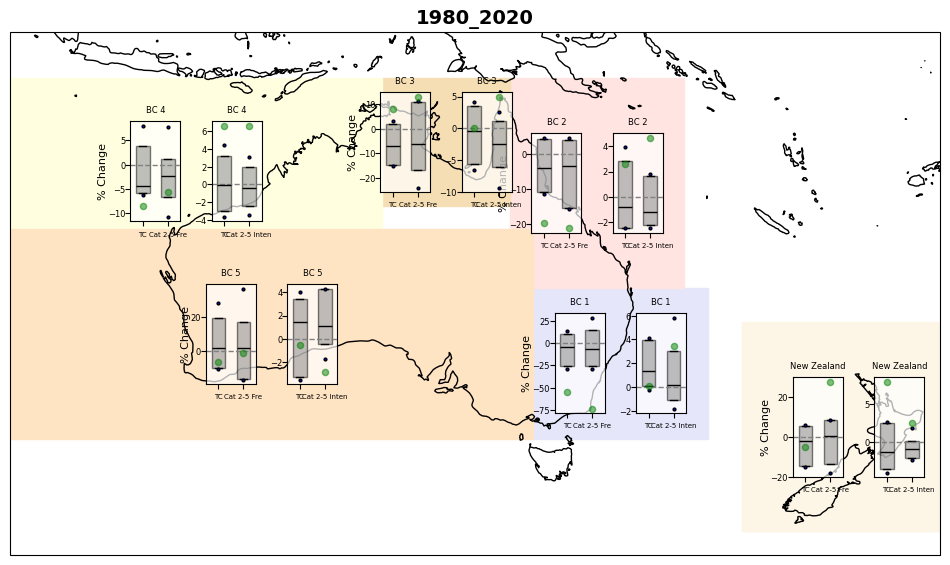

In [8]:
%%time
year_s = 1980
year_e = 2020
print(year_s, year_e)
# (n_var:frequency, intensity, n_region, n_mem, n_cat:TC, >3)
# it's for decade, %, devided by mean
slope_4d_1980_2020 = cal_HR_slope(year_s, year_e)
title_s = str(year_s) + '-' + str(year_e)
#call_box_custom_inset_2p(slope_4d_1980_2020, is_commonY = False, title_s=title_s)
slope_ib = cal_IB_slope(year_s, year_e)
call_box_custom_inset_2p(slope_4d_1980_2020, is_commonY = False, title_s='1980_2020', is_ib=slope_ib)

#### 2020-2100

2020 2100
 Australia Buckley Cyclone Region 1
 Australia Buckley Cyclone Region 2
 Australia Buckley Cyclone Region 3
 Australia Buckley Cyclone Region 4
 Australia Buckley Cyclone Region 5
 New Zealand 


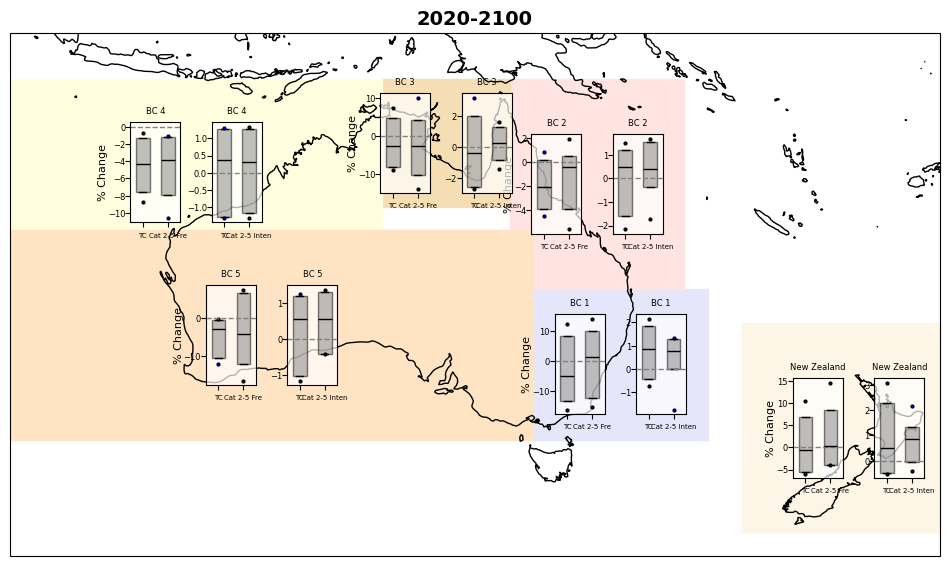

In [9]:
year_s = 2020
year_e = 2100
print(year_s, year_e)
# (n_var:frequency, intensity, n_region, n_mem, n_cat:TC, >3)
# it's for decade, %, devided by mean
slope_4d_2020_2100 = cal_HR_slope(year_s, year_e)
title_s = str(year_s) + '-' + str(year_e)
call_box_custom_inset_2p(slope_4d_2020_2100, is_commonY = False, title_s = title_s)

#### 1980-2100

1980 2100
 Australia Buckley Cyclone Region 1
 Australia Buckley Cyclone Region 2
 Australia Buckley Cyclone Region 3
 Australia Buckley Cyclone Region 4
 Australia Buckley Cyclone Region 5
 New Zealand 


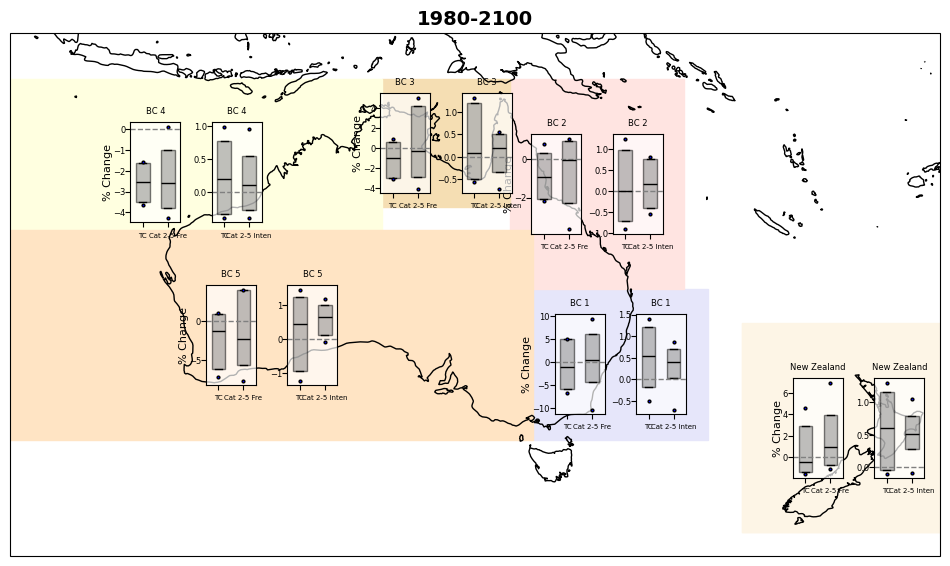

In [10]:
year_s = 1980
year_e = 2100
print(year_s, year_e)
# (n_var:frequency, intensity, n_region, n_mem, n_cat:TC, >3)
# it's for decade, %, devided by mean
slope_4d_1980_2100 = cal_HR_slope(year_s, year_e)
title_s = str(year_s) + '-' + str(year_e)
call_box_custom_inset_2p(slope_4d_1980_2100, is_commonY = False, title_s = title_s)

#### Same set_ylim

In [24]:
def call_box_custom_inset_2p_new(slope_4d, is_commonY = False, title_s='', is_ib=False):
    '''
    is_commonY: the same Y-axis ticks
    n_region, lat_s_1d,  lon_s_1d, read from global variable
    is_ib: False
           True  IB trend as a dot
    '''
    
    # Map locations (latitude, longitude)
    #locations = [(40, -105), (35, -100), (42, -95)]  # (lat, lon)
    latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
    lonc_1_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)-6)/2).tolist()

    # location of 2nd histogram
    lonc_2_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)+6)/2).tolist()
    
    y_title = [['TC', 'Cat 2-5 Fre'], ['TC', 'Cat 2-5 Inten']]
       
    # Create map
    fig = plt.figure(figsize=(10, 6))
    map_ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    map_ax.set_extent([100, 180, -50, -5])
    map_ax.coastlines()

    # Plot histograms at different locations
    # --- Add Inset Boxplots at Each Location ---
    for nr in range(n_region):   
        data_1 = slope_4d[0, nr, :, 0]
        data_2 = slope_4d[0, nr, :, 1]
        data_3 = slope_4d[1, nr, :, 0]
        data_4 = slope_4d[1, nr, :, 1]

        # Add rectangle for bounding box
        bbox = Rectangle((lon_s_1d[nr], lat_s_1d[nr]), lon_e_1d[nr] - lon_s_1d[nr], lat_e_1d[nr] - lat_s_1d[nr],
                 edgecolor=color_s[nr], facecolor=color_s[nr], linewidth=1,
                 transform=ccrs.PlateCarree())

        map_ax.add_patch(bbox)
        
        # Lat/Lon for pinning the boxes        
        locations = [
            {'lat': latc_1d[nr], 'lon': lonc_1_1d[nr],  'ylim': (-30, 50), 'title': region_s[nr], 'x_ticklabel': ['TC Fre', '>=Cat2']},
            {'lat': latc_1d[nr], 'lon': lonc_2_1d[nr],  'ylim': (-5, 10),  'title': '', 'x_ticklabel': ['Int TC', '>=Cat2']}
        ]

        # For each location, convert lat/lon to figure coordinates and add an inset boxplot        
        for nn, loc in enumerate(locations):
            # Convert data (map) coordinates to display coordinates
            x_disp, y_disp = map_ax.transData.transform((loc['lon'], loc['lat']))

            # Convert display to figure coordinates
            fig_x, fig_y = fig.transFigure.inverted().transform((x_disp, y_disp))

            # Create inset axes at the figure coordinate
            #inset_ax = fig.add_axes([fig_x - 0.04, fig_y - 0.05, 0.04, 0.1])
            inset_ax = fig.add_axes([fig_x-0.02 , fig_y-0.03, 0.04, 0.1])
            

            # Boxplot data: group into list
            if nn == 0:
                data = [data_1, data_2]
                q1=5
                q3=95
                inset_ax.set_ylabel("% Change", fontsize=6, labelpad=0)
                
            else:
                data = [data_3, data_4]
                q1=10
                q3=90
                inset_ax.set_ylabel("")
                
            bp=inset_ax.boxplot(data, whis=[q1, q3], showfliers=True,  
                    flierprops=dict(marker='o', color='blue', markersize=3),
                    positions=[1, 2], widths=0.4, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.5),
                     medianprops=dict(color='darkblue'))

            # alpha doesn't work
            # Set transparency (alpha) on the filled boxes
            #for box in bp['boxes']:
            #    box.set_facecolor('blue')  # or any color you like
            #    box.set_alpha(0.5) 

            # Hide whiskers
            for whisker in bp['whiskers']:
                whisker.set_visible(False)
    
            # Add a scatter dot for each box y  
            if not is_ib is False:
                for ii in range(2):
                    xx = ii + 1  # box positions start at 1
                    # slope_ib = np.zeros((n_var, n_region, n_cat))
                    yy = is_ib[nn,nr,ii]  # value of dot (will use IBTracs)
                    inset_ax.scatter(xx, yy, color='green', s=20, alpha=0.5, zorder=3, label='Dot' if ii == 0 else "")
                
            # Add a horizontal line at y=0
            inset_ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
            
            # Customize appearance
            inset_ax.set_ylim(loc['ylim'])
            inset_ax.set_xticks([1, 2])
             
            inset_ax.set_xticklabels(loc['x_ticklabel'])
             
            inset_ax.set_title(loc['title'], fontsize=8)
            inset_ax.tick_params(labelsize=4)
         
    map_ax.set_title(title_s, fontsize=16)

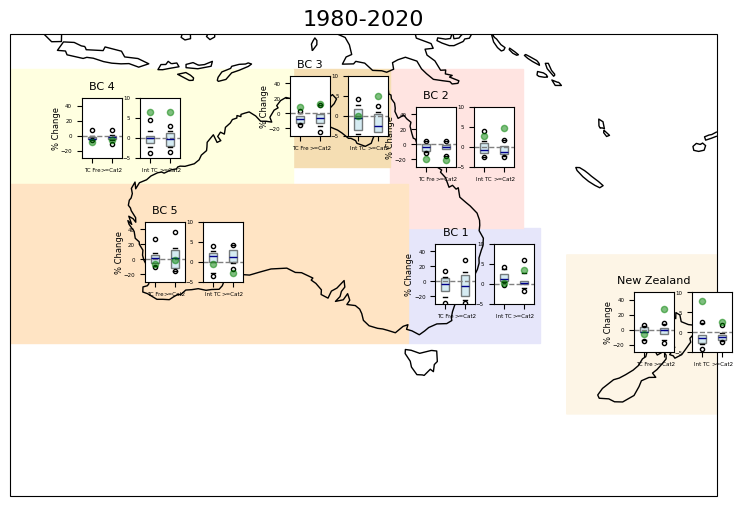

In [25]:
call_box_custom_inset_2p_new(slope_4d_1980_2020, is_commonY = True, title_s='1980-2020', is_ib=slope_ib)

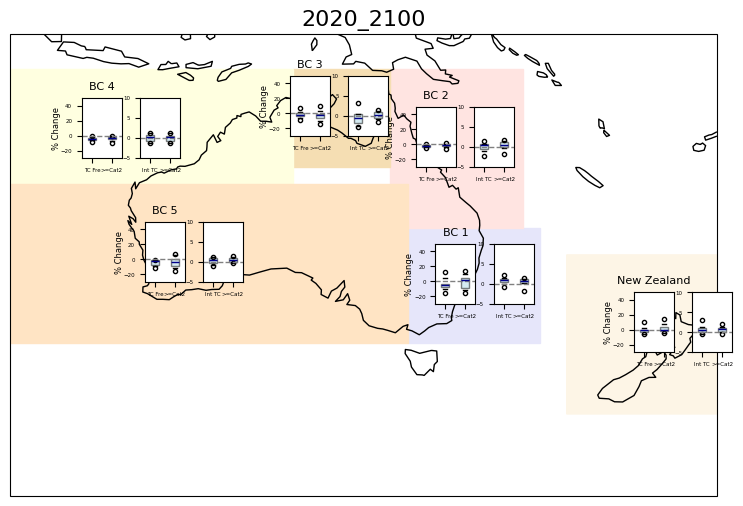

In [26]:
call_box_custom_inset_2p_new(slope_4d_2020_2100, is_commonY = True, title_s='2020_2100', is_ib=False)

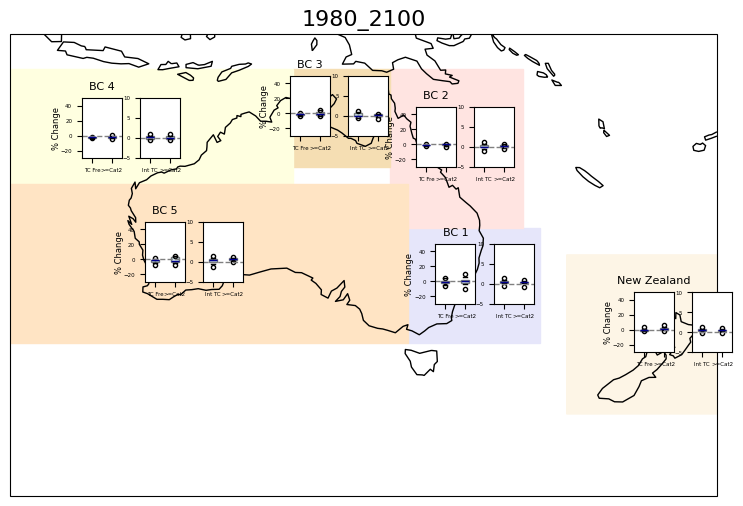

In [27]:
call_box_custom_inset_2p_new(slope_4d_1980_2100, is_commonY = True, title_s='1980_2100', is_ib=False)